In [ ]:
# DEM


# /home/alex/repos/monorepo/external_files/data/DEM/nasa/ASTGTMV003_N42W125_num.tif


# https://search.earthdata.nasa.gov/search?sb[0]=-120.17285%2C33.07207%2C-116.56934%2C34.77651&lat=33.95247465233302&long=-121.03417968750001&zoom=6

# https://wiki.earthdata.nasa.gov/display/EL/How+To+Access+Data+With+Python


# show pipeline:
# open nasa page
# select area
# download tiffs
# put in numpy/tiledb with lat/lng for each image
# demo putting in lat/lng, getting back height ,  e
# merge adjacent tiffs 


# File names are like "N33W121" or "N33W120"
# where W121 is to the left and adjacent to W120
# and N33 is adjacent and just below N34

# merging
# https://rasterio.readthedocs.io/en/latest/api/rasterio.merge.html
# ! rio merge -f GTIFF *.hgt merged.tif
# it knows how to read the geospatial format!!!???





In [9]:

%load_ext autoreload
%autoreload 2



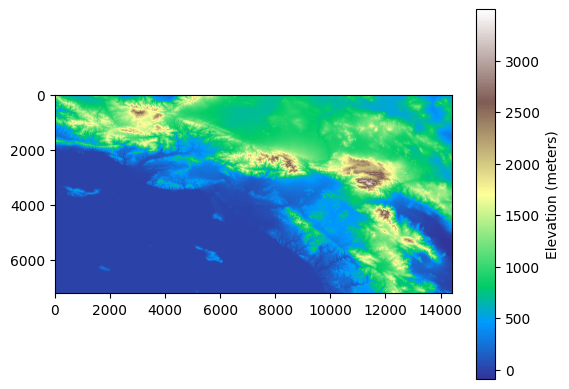

In [1]:


### 

# pip3 install rasterio georasters
# sudo apt install libgdal-dev gdal-bin

import requests
from io import BytesIO
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import rasterio.merge as merge


username = "AlexMoran"
password = "wihtez-jernoR-8fubwo"


def get_dem(north: list[int], west: list[int]):

    output_images = []

    for n in range(north[0], north[-1]):
        
        for w in range(west[0], west[-1]):

            url = f"https://e4ftl01.cr.usgs.gov//DP109/SRTM/SRTMGL1.003/2000.02.11/N{n}W{w}.SRTMGL1.hgt.zip"
            
            with requests.Session() as session:
                    session.auth = (username, password)
                    r1 = session.request('get', url)
                    r = session.get(r1.url, auth=(username, password))
                    if r.ok:
                        bytes_data = BytesIO(r.content)
                        zip_file = zipfile.ZipFile(bytes_data)
                        
                        hgt_content = zip_file.read(f"N{n}W{w}.hgt")
                        side = int(np.sqrt(len(hgt_content) / 2))

                        output_images.append(np.frombuffer(hgt_content, dtype='>i2').reshape((side, side)))

    return output_images


def merge_geotiffs(images, north: list[int], west: list[int]):
    
    north_images = []
    
    for n in range(north[-1] - north[0]):
        count = n * (west[-1] - west[0])
        merged = images[count]
        for w in range(west[-1] - west[0] - 1):
            merged = np.concatenate((images[count + w + 1], merged), axis=1)

        north_images.append(merged)

    merged = north_images[0]
    for i in range(len(north_images) - 1):
        merged = np.concatenate((north_images[i + 1], merged), axis=0)

    return merged


North = [33, 35]
West = [117, 121]

data = get_dem(North, West)

merged = merge_geotiffs(data, North, West)

plt.imshow(merged, cmap='terrain')
plt.colorbar(label='Elevation (meters)')
plt.show()




In [ ]:


### Buffer version


from dataengine.source import DataSources
from dataengine.buffer import DataBuffer
import numpy as np
from dataengine.visualizers.dem import VisTool
import os

os.environ["earthdata_username"] = "AlexMoran"
os.environ["earthdata_password"] = "wihtez-jernoR-8fubwo"


north = [33, 35]
west = [117, 120]

data = DataSources("DEM", bounds=[north, west])

axis = "images"
buffer_depth = (north[-1] - north[0]) * (west[-1] - west[0])
buffer = DataBuffer(data, buffer_depth, use_db=False, axis=axis)



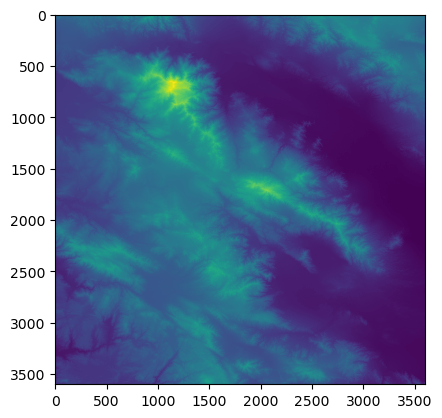

In [2]:

vis_tool = VisTool()

for buf, count in buffer.get_data():
    dat = buf[axis]['data'][-1]

    vis_tool.show(dat)

    break
    
    

Finished loading:  


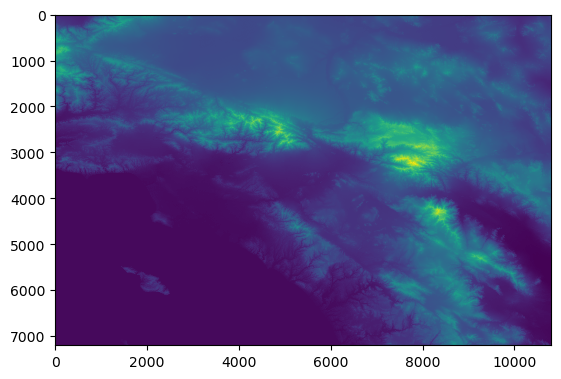

In [3]:


north = [33, 35]
west = [117, 120]

buffer_depth = (north[-1] - north[0]) * (west[-1] - west[0])

vis_tool = VisTool()

source = DataSources("DEM", bounds=[north, west])

buffer = DataBuffer(source, buffer_depth, use_db=False, axis=axis)

buffer.load_data_db(axis)

image = vis_tool.merge_geotiffs(buffer, north, west)

vis_tool.show(image)

